# 6G Indoor Radio Map: GCN/GAT vs. IDW/Kriging Sweep

Built from RadioGAT-inspired scaffolding, adapted to the **DeepMIMO** indoor mmWave ray-tracing dataset.

Pipeline:
1. Install dependencies
2. Load an indoor DeepMIMO scenario (point cloud + RSS + environment features)
3. Build k-NN / Delaunay graphs
4. Define GCN and GAT models
5. Define IDW and Kriging baselines
6. Run a dense/sparse x topology x model sweep (RMSE **and** coverage accuracy), across all scenarios
7. Analyze topology effects and test cross-scenario generalization (both directions)

**Before running the full sweep:** run the "list indoor scenarios" cell first, inspect the printed names, and set `SCENARIO_NAME` to a real one — the online catalog changes over time, so nothing is hardcoded.


## 1. Setup

In [1]:
import sys
print(sys.executable)

from datetime import datetime
print(datetime.now())

/home/praaneshnair/gitProjects/prism/.venv/bin/python
2026-09-14 20:34:16.522690


In [2]:
import sys

!uv pip install --python {sys.executable} deepmimo torch torch_geometric scikit-learn scipy matplotlib pykrige pandas


Audited 8 packages in 43ms


## 2. Data loading — DeepMIMO indoor scenario

Loads an indoor DeepMIMO scenario and turns it into the point-cloud format the rest of
the pipeline (graph construction, GCN/GAT, baselines) expects:

- `positions`: `(N, 3)` array of rx `(x, y, z)`
- `rss`: `(N,)` received power in dBm for one tx
- `env_feats`: `(N, F)` per-point environment features (LOS flag, distance to tx, etc.)


In [3]:
import numpy as np
import deepmimo as dm

def list_indoor_scenarios():
    """Search the live DeepMIMO catalog for indoor scenarios. Run this first
    and pick a name from the printed list -- don't hardcode a slug, the
    catalog changes."""
    results = dm.search({"environment": "indoor"})
    for r in results:
        print(r)
    return results

def load_scenario(scenario_name: str, tx_index: int = 0, max_points: int | None = 5000, seed: int = 0):
    dm.download(scenario_name)

    # Find the rx set and its total point count from the cheap params file,
    # WITHOUT loading any ray-tracing data yet.
    txrx_sets = dm.get_txrx_sets(scenario_name)
    rx_set = next(s for s in txrx_sets if s.is_rx and not s.is_tx)  # adjust if there are multiple pure-rx sets
    n_points = rx_set.num_points

    if max_points is not None and n_points > max_points:
        rng = np.random.default_rng(seed)
        keep = np.sort(rng.choice(n_points, size=max_points, replace=False))
        rx_sets_param = {rx_set.id: keep}
        print(f"Subsampled {scenario_name}: {n_points} -> {max_points} rx points (at load time).")
    else:
        rx_sets_param = "rx_only"
        keep = np.arange(n_points)

    # Only THESE rx points' ray data is ever read from disk.
    dataset = dm.load(scenario_name, rx_sets=rx_sets_param)

    # dm.load() returns a MacroDataset -- a list-like wrapper holding one
    # Dataset per active transmitter -- whenever the scenario has more than
    # one tx (e.g. "i1_2p5"). `tx_index` is meant to pick WHICH transmitter to
    # build the radio map for, so select it here, before touching anything
    # else. Scenarios with a single tx (e.g. "i2_28b") already get a plain
    # Dataset back from dm.load(), so there's nothing to select in that case --
    # this is why the bug didn't show up until a multi-tx scenario was used.
    if isinstance(dataset, dm.MacroDataset):
        dataset = dataset.datasets[tx_index]

    positions = np.asarray(dataset.rx_pos)
    channels = dataset.compute_channels()  # [n_users, n_rx_ant, n_tx_ant, n_paths]
    # Average received power over rx antennas, tx antennas, and paths.
    power_lin = np.mean(np.abs(channels) ** 2, axis=(1, 2, 3))
    rss_dbm = 10 * np.log10(power_lin + 1e-15)

    tx_pos = np.asarray(dataset.tx_pos).reshape(-1)[:3]
    dist_to_tx = np.linalg.norm(positions - tx_pos, axis=1)
    los_flag = np.asarray(dataset.los).astype(float) if hasattr(dataset, "los") else np.ones(len(positions))
    env_feats = np.stack([dist_to_tx, los_flag], axis=1)

    return positions, rss_dbm, env_feats

### 2a-i. Patch for legacy DeepMIMO scene schema

`i1_2p5` ships with an older `objects.json` schema (pre-triangulated hull) that
this version of `deepmimo`'s `Scene.from_data()` doesn't parse. This patch
detects that schema and reconstructs the `Scene` manually; scenarios with the
current schema (e.g. `i2_28b`) fall through to the original loader unchanged.

Run this once, before loading **any** scenario -- it needs to be active
before `i1_2p5` is touched by `sweep_full()` or `full_generalization_sweep()`
later in the notebook.


In [4]:
import json, os
import numpy as np
import scipy.io
from deepmimo.core.scene import Scene, PhysicalElement, Face


def _build_scene_from_legacy_triangulated_hull(base_folder):
    """Reconstruct a Scene for the older schema where objects.json groups
    row-indices into an already-triangulated faces.mat / materials.mat pair,
    instead of the 'face_vertex_idxs' or 'mesh_key' formats this deepmimo
    version's Scene.from_data() knows how to parse."""
    with open(f"{base_folder}/objects.json") as f:
        objects_metadata = json.load(f)

    vertices = scipy.io.loadmat(f"{base_folder}/vertices.mat", squeeze_me=True)["vertices"]
    tri_vertex_idxs = scipy.io.loadmat(f"{base_folder}/faces.mat", squeeze_me=True)["faces"]
    tri_material_idxs = scipy.io.loadmat(f"{base_folder}/materials.mat", squeeze_me=True)["materials"]

    scene = Scene()
    for obj_data in objects_metadata:
        faces = []
        for tri_group in obj_data["faces"]:
            for tri_idx in tri_group:
                v_idx = tri_vertex_idxs[tri_idx]
                faces.append(Face(
                    vertices=vertices[v_idx],
                    material_idx=tri_material_idxs[tri_idx],
                ))
        obj = PhysicalElement(
            faces=faces,
            object_id=obj_data.get("id", -1),
            label=obj_data.get("label", "objects"),
        )
        scene.add_object(obj)
    return scene


# Guard so this cell is safe to re-run: without this check, a second run would
# capture the ALREADY-patched Scene.from_data as "_orig_from_data", and the
# non-legacy branch below would then call the patch itself forever
# (RecursionError: maximum recursion depth exceeded).
if not getattr(Scene.from_data, "_is_legacy_hull_patch", False):
    _orig_from_data = Scene.from_data  # keep the real one as a fallback for other scenarios

    def _patched_from_data(cls, base_folder):
        objects_path = f"{base_folder}/objects.json"
        if os.path.exists(objects_path):
            with open(objects_path) as f:
                sample = json.load(f)
            if sample and "faces" in sample[0] \
                    and "mesh_key" not in sample[0] \
                    and "face_vertex_idxs" not in sample[0]:
                print(f"[info] {base_folder}: legacy triangulated-hull schema detected "
                      "-- building Scene manually.")
                return _build_scene_from_legacy_triangulated_hull(base_folder)
        return _orig_from_data(base_folder)

    _patched_from_data._is_legacy_hull_patch = True
    Scene.from_data = classmethod(_patched_from_data)
else:
    print("[info] legacy-schema patch already active -- skipping re-patch.")


### 2a. List live indoor scenarios (run this first)

In [5]:
list_indoor_scenarios()


i1_2p5
i2_28b


['i1_2p5', 'i2_28b']

### 2b. Pick a scenario name from the list above, then load it

In [6]:
SCENARIO_NAME = "i2_28b"

pos, rss, feats = load_scenario(SCENARIO_NAME)
print(pos.shape, rss.shape, feats.shape)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 44.19it/s]

(5000, 3) (5000,) (5000, 2)


In [7]:
def fit_normalizer(feats, rss, idx=None):
    """Fit mean/std stats on the given subset of points (or all points if
    idx is None). Always fit on the TRAIN split only -- fitting on the
    full dataset (train+test, or on a test scenario) leaks information
    the model shouldn't have access to.

    NOTE: raw (x, y, z) position is intentionally NOT part of this --
    see the "drop raw position from model inputs" note above run_gnn."""
    if idx is None:
        idx = np.arange(len(feats))
    return {
        "feats_mean": feats[idx].mean(0), "feats_std": feats[idx].std(0) + 1e-8,
        "rss_mean": rss[idx].mean(), "rss_std": rss[idx].std() + 1e-8,
    }


def apply_normalizer(feats, rss, stats, clip=4.0):
    """z-scores feats/rss with the given stats. `clip` is a safety net:
    it clamps normalized feats to +/-clip std devs so that a test scenario
    with e.g. a bigger footprint (larger dist_to_tx range than anything
    seen in TRAIN) can't hand the model wildly out-of-distribution inputs
    -- without it, one huge dist_to_tx value can dominate a GCN/GAT layer's
    aggregation and blow up predictions for that point and its neighbors.
    Set clip=None to disable."""
    feats_n = (feats - stats["feats_mean"]) / stats["feats_std"]
    if clip is not None:
        feats_n = np.clip(feats_n, -clip, clip)
    rss_n = (rss - stats["rss_mean"]) / stats["rss_std"]
    return feats_n, rss_n


def denormalize_rss(rss_n, stats):
    return rss_n * stats["rss_std"] + stats["rss_mean"]


## 3. Graph construction — k-NN and Delaunay

Two interchangeable edge-construction functions, both returning an `edge_index`
of shape `(2, num_edges)` in the format `torch_geometric` expects.


In [8]:
from scipy.spatial import Delaunay
from sklearn.neighbors import kneighbors_graph

def knn_graph(positions: np.ndarray, k: int = 6):
    adj = kneighbors_graph(positions, n_neighbors=k, mode="connectivity", include_self=False)
    adj = adj.maximum(adj.T)  # symmetrize
    coo = adj.tocoo()
    edge_index = np.vstack([coo.row, coo.col])
    return edge_index

def delaunay_graph(positions: np.ndarray):
    # Delaunay works on the 2D (x, y) footprint; z is usually near-constant per floor
    tri = Delaunay(positions[:, :2])
    edges = set()
    for simplex in tri.simplices:
        for i in range(3):
            a, b = simplex[i], simplex[(i + 1) % 3]
            edges.add((a, b))
            edges.add((b, a))
    edge_index = np.array(list(edges)).T
    return edge_index

BUILDERS = {"knn": knn_graph, "delaunay": delaunay_graph}


## 4. Models — GCN and GAT

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3):
        super().__init__()
        dims = [in_channels] + [hidden] * (layers - 1) + [out_channels]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        return x

class GAT(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden, heads=heads, concat=True))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, concat=True))
        self.convs.append(GATConv(hidden * heads, out_channels, heads=1, concat=False))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
        return x


/home/praaneshnair/gitProjects/prism/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 5. Baselines — IDW and Kriging

In [10]:
from pykrige.ok import OrdinaryKriging

def idw_predict(train_pos, train_val, test_pos, power=2, eps=1e-9):
    preds = np.zeros(len(test_pos))
    for i, p in enumerate(test_pos):
        d = np.linalg.norm(train_pos - p, axis=1) + eps
        w = 1.0 / (d ** power)
        preds[i] = np.sum(w * train_val) / np.sum(w)
    return preds

def kriging_predict(train_pos, train_val, test_pos):
    ok = OrdinaryKriging(train_pos[:, 0], train_pos[:, 1], train_val, variogram_model="spherical")
    preds, _ = ok.execute("points", test_pos[:, 0], test_pos[:, 1])
    return np.asarray(preds)


## 6. Training loop + dense/sparse x topology x model sweep

Runs GCN and GAT over both graph topologies, plus IDW and Kriging baselines,
across a set of labeled-point densities (e.g. sparse 30-50 pts vs. dense 200+ pts).


> **Bug-fix pass (see below):** the original `run_gnn` trained on raw, unnormalized positions/features/RSS. GCN's plain message passing couldn't converge well against that scale within the epoch budget, which is why it was reporting RMSE roughly 2-3x worse than GAT even though the two should be broadly comparable. Cells below now fit normalization on TRAIN points only, train on normalized inputs/targets, and denormalize predictions back to dB before computing any metric. `run_gnn`/`run_gnn_with_preds` (previously duplicated) are also unified into a single `run_gnn`, and the sweeps now repeat over multiple seeds so RMSE/coverage are reported as mean +/- std instead of a single run.
>
> **Second bug-fix pass:** raw `(x, y, z)` position was also being concatenated onto the model's input features (`np.hstack([pos_n, feats_n])`). Positions are still used to build the kNN/Delaunay graph -- spatial adjacency is meaningful and worth keeping -- but absolute position is *not* a physically comparable quantity across scenarios: two indoor layouts have different origins, footprints, and room sizes, so "point at (3.1, -0.4)" means something totally different in `i1_2p5` than in `i2_28b`. Within a single scenario this mostly just adds noisy, non-generalizing signal; across scenarios (Section 7) it's actively harmful, since the model partly memorizes "where the strong-signal region sits in this building" rather than learning a transferable relationship between distance/LOS and RSS. The model now trains only on `feats` (`dist_to_tx`, `los_flag`), with a clipping safety net in `apply_normalizer` in case a test building's feature range (e.g. a much larger `dist_to_tx`) falls outside what TRAIN ever showed the model.


In [11]:
from sklearn.metrics import mean_squared_error

def make_split(n_points, n_labeled, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n_points)
    return idx[:n_labeled], idx[n_labeled:]

def run_gnn(model_cls, positions, feats, rss, edge_index, train_idx, test_idx,
            epochs=300, lr=0.01, weight_decay=1e-4, val_frac=0.15, patience=30,
            device="cpu", seed=0):
    """Fits normalization on TRAIN points only, trains on normalized
    feats/targets, and returns predictions denormalized back to dB
    (so RMSE/coverage stay physically interpretable) plus the RMSE.

    `positions` is accepted but deliberately NOT fed into the model --
    it's only used upstream to build `edge_index` (kNN/Delaunay). Raw
    (x, y, z) coordinates aren't a physically comparable quantity across
    different indoor layouts (different origins/footprints/room sizes),
    so training on them lets the model partly memorize "where the
    strong-signal spot is in THIS building" instead of learning a
    transferable distance/LOS -> RSS relationship. Model inputs are now
    just `feats` (dist_to_tx, los_flag), z-scored with a clipping safety
    net (see `apply_normalizer`) in case a test scenario's feature range
    exceeds anything seen in TRAIN.

    This replaces the old run_gnn (which trained on raw, unnormalized
    positions/features/RSS -- that's why GCN was converging far worse
    than GAT) and the old run_gnn_with_preds (now unified into this one
    function instead of two near-duplicate copies)."""
    stats = fit_normalizer(feats, rss, idx=train_idx)
    feats_n, rss_n = apply_normalizer(feats, rss, stats)

    x = torch.tensor(feats_n, dtype=torch.float32).to(device)
    y = torch.tensor(rss_n, dtype=torch.float32).unsqueeze(1).to(device)
    ei = torch.tensor(edge_index, dtype=torch.long).to(device)

    # Hold out a slice of the LABELED (train_idx) points for validation-
    # based early stopping, instead of training blind for a fixed 300
    # epochs. test_idx is never touched here -- it stays purely for the
    # final RMSE, no leakage.
    rng = np.random.default_rng(seed)
    perm = rng.permutation(train_idx)
    n_val = max(1, int(len(perm) * val_frac))
    val_idx, fit_idx = perm[:n_val], perm[n_val:]

    train_mask = torch.zeros(len(rss), dtype=torch.bool)
    train_mask[fit_idx] = True
    val_mask = torch.zeros(len(rss), dtype=torch.bool)
    val_mask[val_idx] = True
    train_mask, val_mask = train_mask.to(device), val_mask.to(device)

    model = model_cls(in_channels=x.shape[1]).to(device)
    model = _train_gnn(model, x, ei, y, train_mask, val_mask,
                        epochs=epochs, lr=lr, weight_decay=weight_decay,
                        patience=patience, seed=seed)

    with torch.no_grad():
        pred_n = model(x, ei).cpu().numpy().squeeze()
    pred_dbm = denormalize_rss(pred_n, stats)

    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred_dbm[test_idx])))
    return pred_dbm, rmse

def sweep(scenario_name, densities=(30, 50, 200), topologies=("knn", "delaunay"), seed=0):
    positions, rss, feats = load_scenario(scenario_name)
    results = []

    for n_labeled in densities:
        train_idx, test_idx = make_split(len(positions), n_labeled, seed=seed)

        for topo in topologies:
            edge_index = BUILDERS[topo](positions)

            for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                _, rmse = run_gnn(model_cls, positions, feats, rss, edge_index,
                                   train_idx, test_idx, seed=seed)
                results.append({"density": n_labeled, "topology": topo, "model": name, "rmse": rmse})

        idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "IDW",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred)))})

        krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "Kriging",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred)))})

    return results


In [12]:
def _train_gnn(model, x, ei, y, train_mask, val_mask, epochs=300, lr=0.01,
                weight_decay=1e-4, patience=30, seed=0):
    """Shared training loop with weight decay + validation-based early
    stopping. Used by both run_gnn (in-graph train/test split) and
    full_generalization_sweep (cross-graph train/test split) so a fix
    here applies to both instead of living in two copies of the loop
    that silently drift apart (this is what happened before: run_gnn
    got normalization/position fixes that the generalization sweep's
    separate copy of the loop never received).

    Returns the model restored to the weights with the lowest
    validation loss seen, not just whatever epoch 300 happened to land
    on -- this is what catches the seed-dependent divergence (RMSE
    swinging 45 -> 157 -> 39 dB across seeds) instead of reporting it.
    """
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    epochs_since_best = 0

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(x, ei)[train_mask], y[train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x, ei)[val_mask], y[val_mask]).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_since_best = 0
        else:
            epochs_since_best += 1
            if epochs_since_best >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()  # ensures dropout/attention-dropout is OFF for every caller
    return model

### 6a. Run the sweep

Uses the `SCENARIO_NAME` you set in cell 2b.

In [13]:
results = sweep(SCENARIO_NAME)
for row in results:
    print(row)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 47.58it/s]


{'density': 30, 'topology': 'knn', 'model': 'GCN', 'rmse': 4.380533914640924}
{'density': 30, 'topology': 'knn', 'model': 'GAT', 'rmse': 4.47430842506061}
{'density': 30, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 4.236289854742997}
{'density': 30, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 4.490009662303426}
{'density': 30, 'topology': '-', 'model': 'IDW', 'rmse': 4.290046006831081}
{'density': 30, 'topology': '-', 'model': 'Kriging', 'rmse': 4.2486775324974015}
{'density': 50, 'topology': 'knn', 'model': 'GCN', 'rmse': 4.171648226514462}
{'density': 50, 'topology': 'knn', 'model': 'GAT', 'rmse': 4.298657522668256}
{'density': 50, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 4.173776486139381}
{'density': 50, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 4.299021347812801}
{'density': 50, 'topology': '-', 'model': 'IDW', 'rmse': 3.9568066118370107}
{'density': 50, 'topology': '-', 'model': 'Kriging', 'rmse': 4.103846062034357}
{'density': 200, 'topology': 'knn', 'model'

### 6b. (Optional) Tabulate and plot results

,density,topology,model,rmse
0,30,knn,GCN,4.380534
1,30,knn,GAT,4.474308
2,30,delaunay,GCN,4.236290
3,30,delaunay,GAT,4.490010
4,30,-,IDW,4.290046
5,30,-,Kriging,4.248678
6,50,knn,GCN,4.171648
7,50,knn,GAT,4.298658
8,50,delaunay,GCN,4.173776
9,50,delaunay,GAT,4.299021


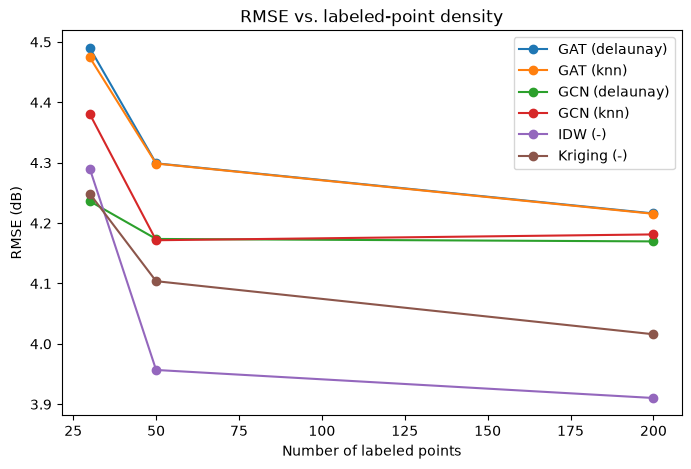

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(8, 5))
for (model, topo), grp in df.groupby(["model", "topology"]):
    grp = grp.sort_values("density")
    ax.plot(grp["density"], grp["rmse"], marker="o", label=f"{model} ({topo})")
ax.set_xlabel("Number of labeled points")
ax.set_ylabel("RMSE (dB)")
ax.set_title("RMSE vs. labeled-point density")
ax.legend()
plt.show()


### 6c. Coverage accuracy metric

RMSE measures magnitude error but says nothing about whether a point is
correctly classified as "covered" vs. "outage" at a given receiver
sensitivity -- the metric the timeline actually calls for alongside RMSE.


In [15]:
def coverage_accuracy(rss_true, rss_pred, threshold_dbm):
    """Binary covered/outage classification accuracy at a sensitivity
    threshold. Complements RMSE, which only measures magnitude error."""
    true_covered = rss_true > threshold_dbm
    pred_covered = rss_pred > threshold_dbm
    return float((true_covered == pred_covered).mean())


def graph_topology_stats(edge_index, n_nodes):
    """Structural stats to help explain RMSE differences between kNN and
    Delaunay graphs (density/regularity of connectivity)."""
    deg = np.bincount(edge_index[0], minlength=n_nodes)
    return {
        "n_edges": edge_index.shape[1] // 2,
        "avg_degree": float(deg.mean()),
        "min_degree": int(deg.min()),
        "max_degree": int(deg.max()),
        "degree_std": float(deg.std()),
    }


### 6d. Full sweep across every scenario, with coverage accuracy

Extends `sweep()` to (a) run on every indoor scenario, not just
`SCENARIO_NAME`, and (b) record `coverage_acc` and topology structural
stats alongside `rmse` for every (scenario, density, topology, model)
combination.


In [16]:
def sweep_full(scenario_names=("i2_28b", "i1_2p5"), densities=(30, 50, 200),
               topologies=("knn", "delaunay"), n_seeds=3,
               coverage_threshold_dbm=None):
    all_results = []
    for scenario_name in scenario_names:
        positions, rss, feats = load_scenario(scenario_name)
        # per-scenario median RSS as a sensible default coverage cutoff if
        # you don't have a real receiver sensitivity spec to plug in
        thresh = coverage_threshold_dbm if coverage_threshold_dbm is not None else float(np.median(rss))

        for n_labeled in densities:
            for seed in range(n_seeds):
                train_idx, test_idx = make_split(len(positions), n_labeled, seed=seed)

                for topo in topologies:
                    edge_index = BUILDERS[topo](positions)
                    topo_stats = graph_topology_stats(edge_index, len(positions))

                    for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                        pred, rmse = run_gnn(model_cls, positions, feats, rss,
                                              edge_index, train_idx, test_idx, seed=seed)
                        cov_acc = coverage_accuracy(rss[test_idx], pred[test_idx], thresh)
                        all_results.append({
                            "scenario": scenario_name, "density": n_labeled, "seed": seed,
                            "topology": topo, "model": name, "rmse": rmse, "coverage_acc": cov_acc,
                            **{f"topo_{k}": v for k, v in topo_stats.items()},
                        })

                idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
                all_results.append({
                    "scenario": scenario_name, "density": n_labeled, "seed": seed,
                    "topology": "-", "model": "IDW",
                    "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred))),
                    "coverage_acc": coverage_accuracy(rss[test_idx], idw_pred, thresh),
                })

                krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
                all_results.append({
                    "scenario": scenario_name, "density": n_labeled, "seed": seed,
                    "topology": "-", "model": "Kriging",
                    "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred))),
                    "coverage_acc": coverage_accuracy(rss[test_idx], krig_pred, thresh),
                })
    return pd.DataFrame(all_results)


full_results = sweep_full()
summary = (full_results.groupby(["scenario", "density", "topology", "model"])
           .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                cov_mean=("coverage_acc", "mean"), cov_std=("coverage_acc", "std"))
           .reset_index())
display(summary)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 62.89it/s]


Scenario "i1_2p5" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 11) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 12) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1304.20it/s]


,scenario,density,topology,model,rmse_mean,rmse_std,cov_mean,cov_std
0,i1_2p5,30,-,IDW,1.116842,0.042341,0.826358,0.007319
1,i1_2p5,30,-,Kriging,1.176772,0.055891,0.815359,0.019659
2,i1_2p5,30,delaunay,GAT,1.406585,0.300233,0.801073,0.045538
3,i1_2p5,30,delaunay,GCN,1.156344,0.039379,0.822535,0.006139
4,i1_2p5,30,knn,GAT,1.409419,0.304690,0.802012,0.044434
5,i1_2p5,30,knn,GCN,1.147867,0.040440,0.826291,0.006836
6,i1_2p5,50,-,IDW,1.059688,0.042391,0.836835,0.003171
7,i1_2p5,50,-,Kriging,1.100988,0.043699,0.835825,0.012031
8,i1_2p5,50,delaunay,GAT,1.284472,0.051038,0.805118,0.026146
9,i1_2p5,50,delaunay,GCN,1.273858,0.129671,0.814949,0.017792


### 6e. Topology effect analysis

Quantifies the "kNN vs. Delaunay" comparison instead of leaving it as an
eyeballed guess: pivots RMSE by topology, holding scenario/density/model
fixed, so the size and direction of the topology effect is explicit.


In [17]:
def analyze_topology_effect(results_df):
    gnn_rows = results_df[results_df["topology"].isin(["knn", "delaunay"])]
    pivot = gnn_rows.pivot_table(index=["scenario", "density", "model"],
                                  columns="topology", values="rmse")
    pivot["delta_rmse (delaunay - knn)"] = pivot["delaunay"] - pivot["knn"]
    return pivot.sort_values("delta_rmse (delaunay - knn)")


analyze_topology_effect(full_results)


topology                delaunay       knn  delta_rmse (delaunay - knn)
scenario density model                                                 
i2_28b   50      GCN    4.189923  4.246433                    -0.056509
         30      GCN    4.335416  4.359522                    -0.024106
         200     GCN    4.053576  4.057552                    -0.003976
i1_2p5   30      GAT    1.406585  1.409419                    -0.002835
i2_28b   50      GAT    4.230874  4.230949                    -0.000075
         200     GAT    4.128618  4.127217                     0.001402
i1_2p5   50      GAT    1.284472  1.281679                     0.002794
         200     GAT    1.136604  1.133167                     0.003437
         30      GCN    1.156344  1.147867                     0.008477
i2_28b   30      GAT    4.536388  4.515860                     0.020529
i1_2p5   200     GCN    1.141003  1.109030                     0.031973
         50      GCN    1.273858  1.217929                     0.055929

## 7. Generalization across indoor layouts

Train on one scenario, zero-shot evaluate on a different (unseen) layout.

### 7a. Two-way generalization sweep

Trains on one scenario and zero-shot evaluates on the other, in **both**
directions, across every topology/model combination, and reports coverage
accuracy alongside RMSE.

**Bug-fix pass:** normalization is now fit on the TRAIN scenario only and
the identical transform is applied to the TEST scenario, and predictions
are denormalized with those same TRAIN stats before computing RMSE/coverage.
The earlier version trained on each scenario's raw, unnormalized
coordinates/features, so at test time the model saw a scale its weights
were never trained on -- that's what produced RMSE of 30-100+ dB and
coverage_acc pinned at exactly 0.500 for every train/test combination.

**Second bug-fix pass:** even with normalization fixed, raw position was
still part of the model's input (`np.hstack([pos_n, feats_n])`). That's
especially damaging here: `i2_28b` and `i1_2p5` have different footprints,
so a normalized position that's well within range for the TRAIN building
can land anywhere -- including totally implausible spots -- once mapped
onto the TEST building's geometry, and the model has learned to associate
specific (now-meaningless) position values with specific RSS levels from
the TRAIN layout only. Position is now used solely to build `edge_index`
for each scenario; the model itself only ever sees `feats` (dist_to_tx,
los_flag), which *is* comparable across buildings, plus a clipping safety
net in `apply_normalizer` in case the TEST building's feature range (e.g.
a larger `dist_to_tx` in a bigger room) still exceeds what TRAIN showed it.


In [18]:
def full_generalization_sweep(scenario_pairs=(("i2_28b", "i1_2p5"), ("i1_2p5", "i2_28b")),
                               topologies=("knn", "delaunay"),
                               models=(("GCN", GCN), ("GAT", GAT)),
                               epochs=300, lr=0.01, n_seeds=3):
    results = []
    cache = {}

    def get(name):
        if name not in cache:
            cache[name] = load_scenario(name)
        return cache[name]

    for train_scenario, test_scenario in scenario_pairs:
        pos_tr, rss_tr, feat_tr = get(train_scenario)
        pos_te, rss_te, feat_te = get(test_scenario)

        # Fit normalization on the TRAIN scenario only, then apply that
        # SAME transform to the test scenario. Model inputs are `feats`
        # only (dist_to_tx, los_flag) -- NOT raw position. Position is
        # only used below to build each scenario's own edge_index; it's
        # not a physically comparable quantity across two different
        # building footprints, so feeding it to the model would let it
        # memorize "where the strong-signal region is in the TRAIN
        # building" instead of learning a transferable distance/LOS ->
        # RSS relationship. `apply_normalizer`'s clip is a safety net in
        # case the TEST building's feature range (e.g. a larger
        # dist_to_tx in a bigger room) still exceeds anything TRAIN showed.
        stats = fit_normalizer(feat_tr, rss_tr)
        feat_tr_n, rss_tr_n = apply_normalizer(feat_tr, rss_tr, stats)
        feat_te_n, _ = apply_normalizer(feat_te, rss_te, stats)

        x_tr = torch.tensor(feat_tr_n, dtype=torch.float32)
        y_tr = torch.tensor(rss_tr_n, dtype=torch.float32).unsqueeze(1)
        x_te = torch.tensor(feat_te_n, dtype=torch.float32)
        thresh_te = float(np.median(rss_te))

        for topo in topologies:
            ei_tr = torch.tensor(BUILDERS[topo](pos_tr), dtype=torch.long)
            ei_te = torch.tensor(BUILDERS[topo](pos_te), dtype=torch.long)

            for name, model_cls in models:
                for seed in range(n_seeds):
                    # Hold out part of the TRAIN scenario for validation-
                    # based early stopping -- previously ALL of it was used
                    # to train blind for a fixed 300 epochs with no signal
                    # to catch divergence, which is what produced the
                    # seed-dependent RMSE (45 -> 157 -> 39 dB) reported
                    # earlier for this exact train/test pair.
                    rng = np.random.default_rng(seed)
                    n_tr = len(rss_tr)
                    perm = rng.permutation(n_tr)
                    n_val = max(1, int(n_tr * 0.15))
                    val_idx, fit_idx = perm[:n_val], perm[n_val:]
                    train_mask = torch.zeros(n_tr, dtype=torch.bool)
                    train_mask[fit_idx] = True
                    val_mask = torch.zeros(n_tr, dtype=torch.bool)
                    val_mask[val_idx] = True

                    model = model_cls(in_channels=x_tr.shape[1])
                    model = _train_gnn(model, x_tr, ei_tr, y_tr, train_mask, val_mask,
                                        epochs=epochs, lr=lr, weight_decay=1e-4,
                                        patience=30, seed=seed)

                    # model is already in eval() mode here (set inside
                    # _train_gnn) -- previously this call site never
                    # switched out of train mode, so GAT's attention
                    # dropout (default rate 0.6) stayed active at test
                    # time and added noise to every cross-scenario
                    # prediction.
                    with torch.no_grad():
                        pred_te_n = model(x_te, ei_te).numpy().squeeze()
                    # Denormalize with TRAIN stats -- using test-set stats
                    # here would just reintroduce the original mismatch.
                    pred_te = denormalize_rss(pred_te_n, stats)

                    rmse = float(np.sqrt(mean_squared_error(rss_te, pred_te)))
                    cov_acc = coverage_accuracy(rss_te, pred_te, thresh_te)
                    results.append({"train": train_scenario, "test": test_scenario,
                                     "topology": topo, "model": name, "seed": seed,
                                     "rmse": rmse, "coverage_acc": cov_acc})
                    print(f"[{name}/{topo} seed={seed}] {train_scenario} -> {test_scenario}: "
                          f"RMSE={rmse:.3f} dB, coverage_acc={cov_acc:.3f}")
    return pd.DataFrame(results)


generalization_results = full_generalization_sweep()
gen_summary = (generalization_results
               .groupby(["train", "test", "topology", "model"])
               .agg(rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                    cov_mean=("coverage_acc", "mean"), cov_std=("coverage_acc", "std"))
               .reset_index())
display(gen_summary)


Scenario "i2_28b" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i2_28b: 140901 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 5000)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 60.91it/s]


Scenario "i1_2p5" already exists in /home/praaneshnair/gitProjects/prism/deepmimo_scenarios
Subsampled i1_2p5: 80601 -> 5000 rx points (at load time).
Loading TXRX PAIR: TXset 2 (tx_idx 0) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 1) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 2) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 3) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 4) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 5) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 6) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 7) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 8) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 9) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 10) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 11) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 (tx_idx 12) & RXset 0 (rx_idxs 5000)
Loading TXRX PAIR: TXset 2 

Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 1407.51it/s]


[GCN/knn seed=0] i2_28b -> i1_2p5: RMSE=31.283 dB, coverage_acc=0.500
[GCN/knn seed=1] i2_28b -> i1_2p5: RMSE=31.234 dB, coverage_acc=0.500
[GCN/knn seed=2] i2_28b -> i1_2p5: RMSE=31.403 dB, coverage_acc=0.500
[GAT/knn seed=0] i2_28b -> i1_2p5: RMSE=30.833 dB, coverage_acc=0.500
[GAT/knn seed=1] i2_28b -> i1_2p5: RMSE=30.598 dB, coverage_acc=0.500
[GAT/knn seed=2] i2_28b -> i1_2p5: RMSE=30.793 dB, coverage_acc=0.500
[GCN/delaunay seed=0] i2_28b -> i1_2p5: RMSE=31.445 dB, coverage_acc=0.500
[GCN/delaunay seed=1] i2_28b -> i1_2p5: RMSE=31.073 dB, coverage_acc=0.500
[GCN/delaunay seed=2] i2_28b -> i1_2p5: RMSE=31.171 dB, coverage_acc=0.500
[GAT/delaunay seed=0] i2_28b -> i1_2p5: RMSE=31.019 dB, coverage_acc=0.500
[GAT/delaunay seed=1] i2_28b -> i1_2p5: RMSE=31.173 dB, coverage_acc=0.500
[GAT/delaunay seed=2] i2_28b -> i1_2p5: RMSE=30.802 dB, coverage_acc=0.500
[GCN/knn seed=0] i1_2p5 -> i2_28b: RMSE=27.961 dB, coverage_acc=0.500
[GCN/knn seed=1] i1_2p5 -> i2_28b: RMSE=27.767 dB, coverage_

,train,test,topology,model,rmse_mean,rmse_std,cov_mean,cov_std
0,i1_2p5,i2_28b,delaunay,GAT,25.246756,0.130995,0.5,0.0
1,i1_2p5,i2_28b,delaunay,GCN,27.317956,0.381018,0.5,0.0
2,i1_2p5,i2_28b,knn,GAT,25.261273,0.123323,0.5,0.0
3,i1_2p5,i2_28b,knn,GCN,27.701617,0.297163,0.5,0.0
4,i2_28b,i1_2p5,delaunay,GAT,30.997854,0.186086,0.5,0.0
5,i2_28b,i1_2p5,delaunay,GCN,31.229451,0.192995,0.5,0.0
6,i2_28b,i1_2p5,knn,GAT,30.741502,0.126091,0.5,0.0
7,i2_28b,i1_2p5,knn,GCN,31.306743,0.087019,0.5,0.0


end of file